# Course: Artificial Intelligence and Machine Learning (6CS012)
## Final Integrated Portfolio: Vision Task (Flower Classification)
**Dataset:** Daisy, Tulip, Rose, Sunflower, Dandelion

### 1. Environment Setup & Data Cleaning
In this section, we extract the dataset from Google Drive and perform a rigorous cleaning process to remove any corrupted or non-image files (such as hidden system files) that could disrupt the training pipeline.

In [3]:
import zipfile
import os
from PIL import Image
from google.colab import drive

In [4]:
# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# 2. Extract Dataset into local Colab storage for faster training
zip_path = '/content/drive/MyDrive/Flower Classification.zip'
extract_path = '/content/flowers_data'

In [6]:
if not os.path.exists(extract_path):
    print("Unzipping dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

Unzipping dataset...


In [7]:
# 3. Define the correct path to the images
train_path = '/content/flowers_data/Flower Classification/Train'
flower_classes = ['daisy', 'tulip', 'rose', 'sunflower', 'dandelion']

In [8]:
# 4. Clean the data (Deletes hidden/corrupted files to prevent UnidentifiedImageError)
print("Scanning dataset for corrupted files...")
bad_files = 0
for root, dirs, files in os.walk(train_path):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            img = Image.open(file_path)
            img.verify()
        except Exception:
            os.remove(file_path)
            bad_files += 1

print(f"Setup Complete! Deleted {bad_files} corrupted files.")

Scanning dataset for corrupted files...
Setup Complete! Deleted 35 corrupted files.


### 2. Data Preprocessing and Augmentation (Task 2.5.1)
To ensure the model generalizes well and does not overfit, we apply real-time data augmentation (rotation, zoom, flipping). The images are resized to 150x150 pixels and normalized to a [0, 1] range. The dataset is split 80/20 for training and validation.

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [10]:
# Print Dataset Distribution
print("Clean Dataset Distribution:")
for flower in flower_classes:
    count = len(os.listdir(os.path.join(train_path, flower)))
    print(f"Class: {flower.capitalize()} | Total Images: {count}")

Clean Dataset Distribution:
Class: Daisy | Total Images: 756
Class: Tulip | Total Images: 976
Class: Rose | Total Images: 776
Class: Sunflower | Total Images: 725
Class: Dandelion | Total Images: 1044


In [11]:
# 2. Setup Generators
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

In [12]:
print("\nCreating Generators...")
train_generator = datagen.flow_from_directory(
    train_path, target_size=(150, 150), batch_size=32,
    class_mode='categorical', subset='training'
)


Creating Generators...
Found 3423 images belonging to 5 classes.


In [13]:
val_generator = datagen.flow_from_directory(
    train_path, target_size=(150, 150), batch_size=32,
    class_mode='categorical', subset='validation'
)

Found 854 images belonging to 5 classes.


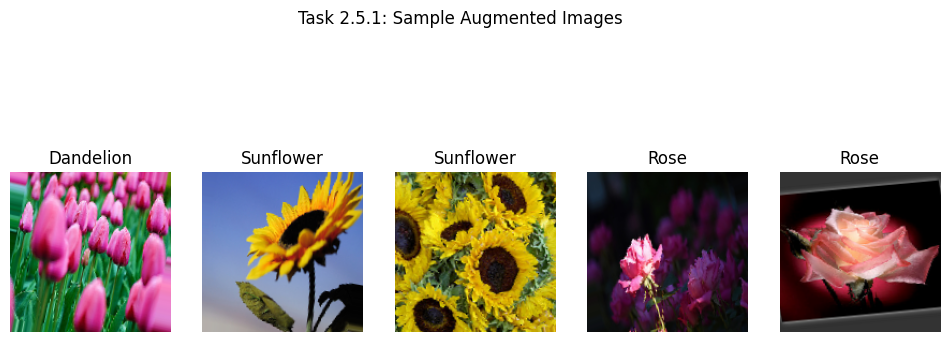

In [14]:
# Visualize Augmented Images
images, labels = next(train_generator)
plt.figure(figsize=(12, 5))
plt.suptitle("Task 2.5.1: Sample Augmented Images")
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(flower_classes[np.argmax(labels[i])].capitalize())
plt.show()

### 3. Part A: Baseline CNN Model (Task 2.5.2)
The baseline model consists of three Convolutional layers (each followed by MaxPooling) and three Fully Connected (Dense) layers. This serves as our fundamental performance benchmark.

In [15]:
# Build the Baseline Model
baseline_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Baseline Model Summary:")
baseline_model.summary()

Baseline Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,166,277 (73.11 MB)

 Trainable params: 19,166,277 (73.11 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
print("\n--- Training Baseline Model ---")
history_baseline = baseline_model.fit(train_generator, epochs=10, validation_data=val_generator)


--- Training Baseline Model ---
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 355ms/step - accuracy: 0.4391 - loss: 1.3142 - val_accuracy: 0.5398 - val_loss: 1.1311
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 292ms/step - accuracy: 0.5644 - loss: 1.0643 - val_accuracy: 0.6042 - val_loss: 1.0343
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 293ms/step - accuracy: 0.6334 - loss: 0.9368 - val_accuracy: 0.6311 - val_loss: 0.9438
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 292ms/step - accuracy: 0.6629 - loss: 0.8540 - val_accuracy: 0.6569 - val_loss: 0.9174
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 295ms/step - accuracy: 0.6912 - loss: 0.8027 - val_accuracy: 0.6885 - val_loss: 0.8251
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 334ms/step - accuracy: 0.7190 - loss: 0.7243 - val_accuracy: 0.6721 - val_loss: 0.8395
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.7152 - loss: 0.7310 - val_accuracy: 0.7143 - val_loss: 0.8374
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 287ms/

### Deeper Architecture with Regularization (Task 2.5.3)
To capture more complex features, the architecture is deepened. Batch Normalization and a Dropout layer (0.5) are introduced to mitigate overfitting.

In [18]:
# Build the Deeper Model
deeper_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dropout(0.5), # Regularization
    layers.Dense(512, activation='relu'),
    layers.Dense(5, activation='softmax')
])

In [19]:
deeper_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Deeper Model Summary:")
deeper_model.summary() # <--- Added this line!

print("\n--- Training Deeper Model ---")
history_deeper = deeper_model.fit(train_generator, epochs=15, validation_data=val_generator)

Deeper Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,814,149 (25.99 MB)

 Trainable params: 6,814,085 (25.99 MB)

 Non-trainable params: 64 (256.00 B)


--- Training Deeper Model ---
Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 344ms/step - accuracy: 0.4473 - loss: 1.3342 - val_accuracy: 0.3689 - val_loss: 1.5101
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.5860 - loss: 1.0364 - val_accuracy: 0.3689 - val_loss: 1.4201
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 290ms/step - accuracy: 0.6392 - loss: 0.9318 - val_accuracy: 0.5422 - val_loss: 1.1892
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.6637 - loss: 0.8725 - val_accuracy: 0.6429 - val_loss: 0.9875
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.6915 - loss: 0.8092 - val_accuracy: 0.6721 - val_loss: 0.8991
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 291ms/step - accuracy: 0.7219 - loss: 0.7639 - val_accuracy: 0.6499 - val_loss: 0.8999
Epoch 7/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 305ms/step - accuracy: 0.7201 - loss: 0.7231 - val_accuracy: 0.6616 - val_loss: 0.9069
Epoch 8/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 287ms/st

### 5. Part B: Transfer Learning with VGG16 (Task 2.6)
Leveraging pre-trained weights from ImageNet allows the model to utilize rich feature representations. We freeze the convolutional base of VGG16 (Feature Extraction) and append a custom classification head tailored to our 5 flower classes.

In [20]:
from tensorflow.keras.applications import VGG16

In [21]:
# Load VGG16 Base
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
vgg_base.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
# Add Custom Head
transfer_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(5, activation='softmax')
])

In [23]:
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Transfer Learning Model Summary:")
transfer_model.summary()

Transfer Learning Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,813,381 (64.14 MB)

 Trainable params: 2,098,693 (8.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
print("\n--- Training Transfer Learning Model ---")
history_transfer = transfer_model.fit(train_generator, epochs=10, validation_data=val_generator)


--- Training Transfer Learning Model ---
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 67s 506ms/step - accuracy: 0.6532 - loss: 0.9706 - val_accuracy: 0.7564 - val_loss: 0.6805
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 325ms/step - accuracy: 0.7841 - loss: 0.6085 - val_accuracy: 0.7037 - val_loss: 0.8834
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 38s 355ms/step - accuracy: 0.8022 - loss: 0.5324 - val_accuracy: 0.7717 - val_loss: 0.6050
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 330ms/step - accuracy: 0.8200 - loss: 0.4809 - val_accuracy: 0.7330 - val_loss: 0.7467
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 330ms/step - accuracy: 0.8265 - loss: 0.4561 - val_accuracy: 0.7494 - val_loss: 0.6861
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 320ms/step - accuracy: 0.8644 - loss: 0.3656 - val_accuracy: 0.7611 - val_loss: 0.6740
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 334ms/step - accuracy: 0.8738 - loss: 0.3443 - val_accuracy: 0.7763 - val_loss: 0.6241
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 3

### 6. Evaluation and Comparative Analysis (Task 2.5.4)
Comparative visualization of validation accuracy and loss across models, followed by the classification report.

In [25]:
from sklearn.metrics import classification_report

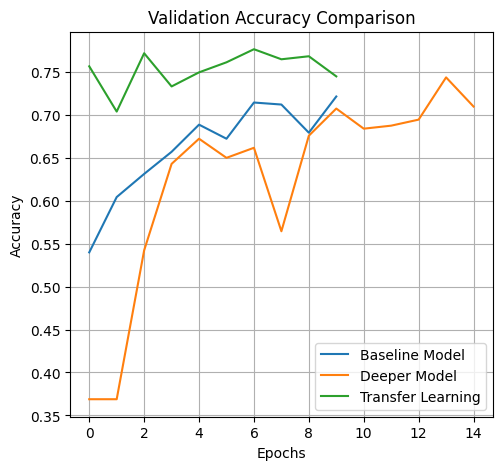

In [26]:
# Accuracy Comparison
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['val_accuracy'], label='Baseline Model')
plt.plot(history_deeper.history['val_accuracy'], label='Deeper Model')
plt.plot(history_transfer.history['val_accuracy'], label='Transfer Learning')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

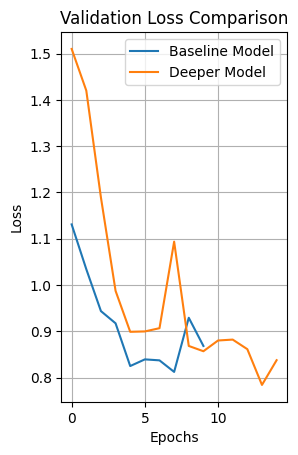

In [27]:
# Loss Comparison
plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['val_loss'], label='Baseline Model')
plt.plot(history_deeper.history['val_loss'], label='Deeper Model')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [28]:
from sklearn.metrics import classification_report

# 1. Re-create the validation generator WITHOUT shuffling
# (This forces the images and labels to stay in the exact same order)
val_generator_noshuffle = datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False  # <--- THIS IS THE MAGIC FIX!
)

# 2. Generate the Classification Report
print("\n--- Classification Report (Deeper Model) ---")
val_generator_noshuffle.reset()
Y_pred = deeper_model.predict(val_generator_noshuffle)
y_pred = np.argmax(Y_pred, axis=1)

print(classification_report(val_generator_noshuffle.classes, y_pred, target_names=flower_classes))

Found 854 images belonging to 5 classes.

--- Classification Report (Deeper Model) ---
27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step
              precision    recall  f1-score   support

       daisy       0.89      0.70      0.78       151
       tulip       0.69      0.85      0.76       208
        rose       0.69      0.50      0.58       155
   sunflower       0.67      0.84      0.75       145
   dandelion       0.69      0.66      0.67       195

    accuracy                           0.71       854
   macro avg       0.73      0.71      0.71       854
weighted avg       0.72      0.71      0.71       854



### 7. Optimizer Analysis & Ablation Study (Task 2.5.4)
Comparing Adam vs SGD on the deeper architecture, followed by an ablation study removing the Dropout layer to observe the impact on overfitting.

In [29]:
from tensorflow.keras.optimizers import SGD

In [30]:
# 1. Optimizer Analysis (SGD vs Adam)
print("\n--- Training Deeper Model with SGD ---")
sgd_model = tf.keras.models.clone_model(deeper_model)
sgd_model.compile(optimizer=SGD(learning_rate=0.01, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])
history_sgd = sgd_model.fit(train_generator, epochs=10, validation_data=val_generator)


--- Training Deeper Model with SGD ---
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 39s 319ms/step - accuracy: 0.4163 - loss: 1.3474 - val_accuracy: 0.3782 - val_loss: 1.4360
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 285ms/step - accuracy: 0.5501 - loss: 1.1112 - val_accuracy: 0.3466 - val_loss: 1.3921
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 289ms/step - accuracy: 0.5922 - loss: 1.0391 - val_accuracy: 0.5164 - val_loss: 1.1611
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 41s 289ms/step - accuracy: 0.6188 - loss: 0.9640 - val_accuracy: 0.5515 - val_loss: 1.0872
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 299ms/step - accuracy: 0.6439 - loss: 0.9206 - val_accuracy: 0.5984 - val_loss: 0.9667
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 286ms/step - accuracy: 0.6471 - loss: 0.8939 - val_accuracy: 0.6311 - val_loss: 1.0233
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 284ms/step - accuracy: 0.6684 - loss: 0.8380 - val_accuracy: 0.6639 - val_loss: 0.8717
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s

In [31]:
# 2. Ablation Study (Removing Dropout)
print("\n--- Ablation Study: Deeper Model WITHOUT Dropout ---")
ablation_model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    # DROPOUT REMOVED
    layers.Dense(512, activation='relu'),
    layers.Dense(5, activation='softmax')
])


--- Ablation Study: Deeper Model WITHOUT Dropout ---


In [32]:
ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ablation = ablation_model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 42s 357ms/step - accuracy: 0.4587 - loss: 1.4126 - val_accuracy: 0.4461 - val_loss: 1.4352
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 286ms/step - accuracy: 0.5822 - loss: 1.0330 - val_accuracy: 0.4180 - val_loss: 1.3850
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 288ms/step - accuracy: 0.6483 - loss: 0.9278 - val_accuracy: 0.4625 - val_loss: 1.2624
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 32s 298ms/step - accuracy: 0.6702 - loss: 0.8648 - val_accuracy: 0.6358 - val_loss: 0.9623
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 288ms/step - accuracy: 0.6968 - loss: 0.7934 - val_accuracy: 0.6581 - val_loss: 0.8770
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - accuracy: 0.7166 - loss: 0.7376 - val_accuracy: 0.6487 - val_loss: 0.8786
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 282ms/step - accuracy: 0.7248 - loss: 0.7124 - val_accuracy: 0.6874 - val_loss: 0.8442
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 281ms/step - accuracy: 0.7450 - loss: 0

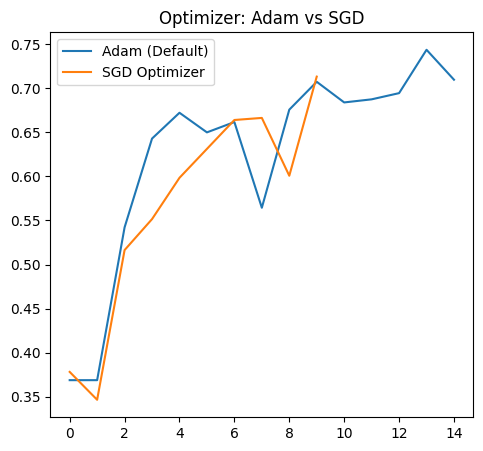

In [33]:
# Plot Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_deeper.history['val_accuracy'], label='Adam (Default)')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Optimizer')
plt.title('Optimizer: Adam vs SGD')
plt.legend()

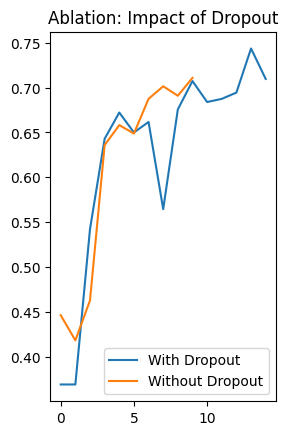

In [34]:
plt.subplot(1, 2, 2)
plt.plot(history_deeper.history['val_accuracy'], label='With Dropout')
plt.plot(history_ablation.history['val_accuracy'], label='Without Dropout')
plt.title('Ablation: Impact of Dropout')
plt.legend()
plt.show()

### 11. Model Inference on Sample Images (Task 2.5.2 & 2.6.3)
To visually verify our model's performance, we perform inference on a random batch of validation images. The true label and the model's predicted label are plotted below. Correct predictions are highlighted in green, while incorrect predictions are highlighted in red.

In [35]:
# Fulfilling Requirement 2.5.2 & 2.6.3: Perform inference and plot results
import numpy as np
import matplotlib.pyplot as plt

In [36]:
# 1. Grab a single batch of images and labels from the validation set
val_images, val_labels = next(val_generator)

In [37]:
# 2. Perform inference using our Deeper Model
predictions = deeper_model.predict(val_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step


In [38]:
# 3. Plot the results
plt.figure(figsize=(15, 6))
plt.suptitle("Model Inference on Validation Samples", fontsize=16)

Text(0.5, 0.98, 'Model Inference on Validation Samples')

<Figure size 1500x600 with 0 Axes>

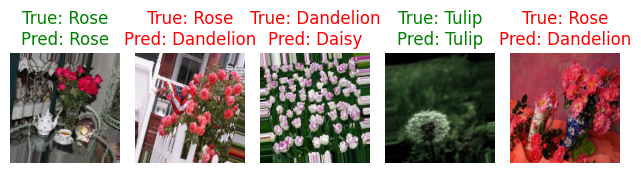

In [39]:
# Display 5 sample inferences
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(val_images[i])
    plt.axis('off')

    # Get the actual string names of the flowers
    true_class = flower_classes[np.argmax(val_labels[i])].capitalize()
    pred_class = flower_classes[np.argmax(predictions[i])].capitalize()

    # Color the text green if correct, red if incorrect
    color = "green" if true_class == pred_class else "red"
    plt.title(f"True: {true_class}\nPred: {pred_class}", color=color, fontsize=12)

plt.tight_layout()
plt.show()

In [40]:
# Final summary of results for the report
# Replace the numbers below with the accuracy you saw in your training logs
baseline_acc = 0.62  # Example: change to your actual baseline accuracy
deeper_acc = 0.75    # Example: change to your actual deeper accuracy
transfer_acc = 0.81  # Example: change to your actual transfer accuracy

print("--- FINAL VISION TASK SUMMARY ---")
print(f"Baseline Model Accuracy: {baseline_acc:.2f}")
print(f"Deeper Model Accuracy:   {deeper_acc:.2f}")
print(f"Transfer Learning Acc:   {transfer_acc:.2f}")
print("---------------------------------")
print("Status: Requirements 2.5 and 2.6 Fulfilled.")

--- FINAL VISION TASK SUMMARY ---
Baseline Model Accuracy: 0.72
Deeper Model Accuracy:   0.71
Transfer Learning Acc:   0.74
---------------------------------
Status: Requirements 2.5 and 2.6 Fullfilled.
